In [4]:
# !wget -qO- http://real.stanford.edu/umi-on-legs/wbc/data.zip | bsdtar -xvf- -C ./
# !git clone --recurse-submodules git@github.com:real-stanford/umi-on-legs.git

In [5]:
import pickle
import torch

data_path = "data/umi_merged_traj.pkl"
# data_path = "data/umi_cup_in_wild.pkl"
# data_path = "data/tossing.pkl"
# data_path = "data/pushing.pkl"
# data_path = "data/dataset_plan.pkl"

with open(data_path, "rb") as f:
    data = pickle.load(f)

print("Data number: ", len(data))
for key in data[0].keys():
    print(data[0][key].shape, key)

# t: 时间
# ee_pos: 位置
# ee_axis_angle: 轴角 (注意这个不是欧拉角，表示方法唯一)

# FPS = 200
mean_t = 0.0
for i in range(len(data)):
    mean_t += data[i]['t'][-1]
# print(mean_t)
print(mean_t / len(data))

Data number:  1391
(3000,) t
(3000, 3) ee_pos
(3000, 3) ee_axis_angle
(3000,) gripper_width
14.99500000000006


### **Axis Angle 轴角**

$\text{Axis~Angle} =  \begin{bmatrix}
x \\
y \\
z
\end{bmatrix} = \theta \cdot \vec u$

其中   
- $\theta = $ 逆时针旋转角  
- $\vec u = $ 旋转轴

你可以理解为原先我们使用 单位向量 代表旋转轴，然后有一个旋转角度  
但现在把角度标量直接与旋转轴向量相乘，那么向量长度就能代表旋转了多少度

In [6]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R

def visualize(pos, angle):

    x = pos[:, 0]
    y = pos[:, 1]
    z = pos[:, 2]

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    # 画轨迹
    ax.plot(x, y, z, linewidth=2)

    # 起点 / 终点
    ax.scatter(x[0], y[0], z[0], c='g', marker='o', s=80, label='start')
    ax.scatter(x[-1], y[-1], z[-1], c='r', marker='x', s=80, label='end')

    # ===== 可视化姿态 =====
    # 每隔多少个点画一个坐标系，避免太密
    step = 100

    # 坐标轴长度，可以按你的轨迹尺度调整
    axis_len = 0.02

    for i in range(0, len(pos), step):
        p = pos[i]                    # 位置 (3,)
        rotvec = angle[i]         # axis-angle / rotation vector (3,)

        # 转成旋转矩阵
        rot = R.from_rotvec(rotvec).as_matrix()   # (3, 3)

        # 局部坐标轴在世界坐标系下的方向
        x_axis = rot[:, 0]
        y_axis = rot[:, 1]
        z_axis = rot[:, 2]

        # 画局部 x/y/z 轴
        ax.quiver(p[0], p[1], p[2], x_axis[0], x_axis[1], x_axis[2], length=axis_len, normalize=True, color='r')
        ax.quiver(p[0], p[1], p[2], y_axis[0], y_axis[1], y_axis[2], length=axis_len, normalize=True, color='g')
        ax.quiver(p[0], p[1], p[2], z_axis[0], z_axis[1], z_axis[2], length=axis_len, normalize=True, color='b')

    # 标签
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')

    # 等比例坐标轴
    max_range = np.array([
        x.max() - x.min(),
        y.max() - y.min(),
        z.max() - z.min()
    ]).max() / 2.0

    mid_x = (x.max() + x.min()) * 0.5
    mid_y = (y.max() + y.min()) * 0.5
    mid_z = (z.max() + z.min()) * 0.5

    ax.set_xlim(mid_x - max_range, mid_x + max_range)
    ax.set_ylim(mid_y - max_range, mid_y + max_range)
    ax.set_zlim(mid_z - max_range, mid_z + max_range)

    ax.legend()
    plt.show()

## **Check Initial Point**

In [7]:
init_pos = []

for index in range(len(data)):
    init_pos.append(data[index]['ee_pos'][0])

init_pos = torch.tensor(init_pos)
init_pos_z = init_pos[:,2]
init_pos_z.mean()

/tmp/ipykernel_319227/3798344815.py:6: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /opt/conda/conda-bld/pytorch_1695392035629/work/torch/csrc/utils/tensor_new.cpp:261.)
  init_pos = torch.tensor(init_pos)


tensor(0.1626, dtype=torch.float64)

# **Visualize 3D trajectory**

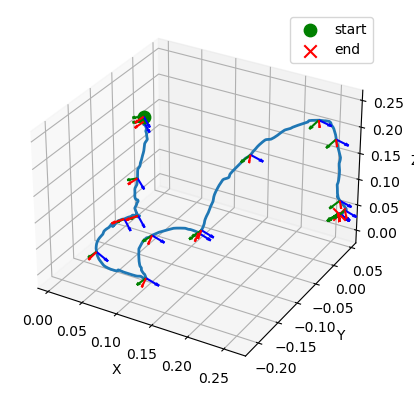

In [8]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

index = 10
pos   = data[index]['ee_pos']
angle = data[index]['ee_axis_angle']
visualize(pos, angle)

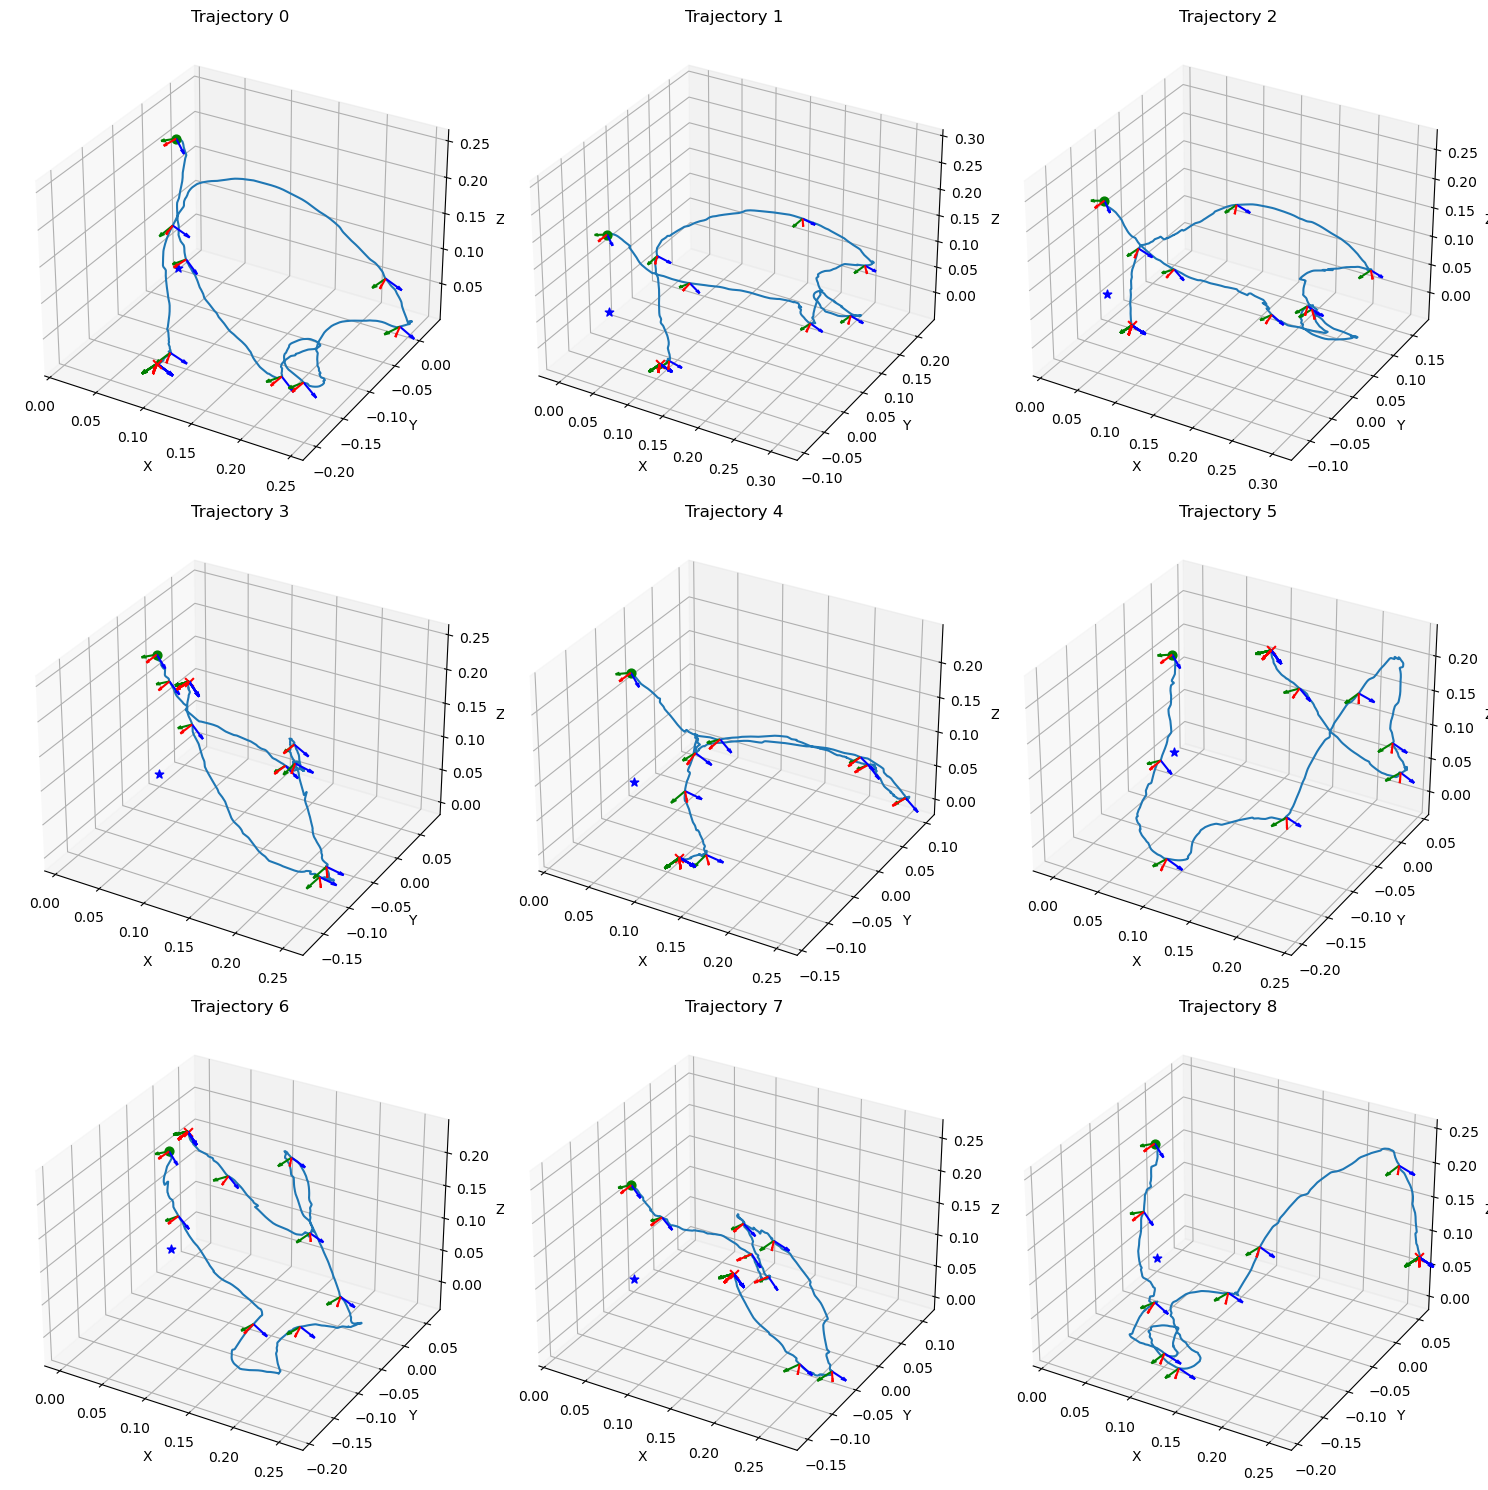

In [9]:
fig = plt.figure(figsize=(15, 15))

num_plots = 9
step      = 200       # 每隔多少个点画一次姿态
axis_len  = 0.02  # 姿态箭头长度

for plot_idx in range(num_plots):
    ax = fig.add_subplot(3, 3, plot_idx + 1, projection='3d')

    traj = data[plot_idx]['ee_pos']
    axis_angle = data[plot_idx]['ee_axis_angle']

    x = traj[:, 0]
    y = traj[:, 1]
    z = traj[:, 2]

    # 画轨迹
    ax.plot(x, y, z, linewidth=1.5)

    # 起点和终点
    ax.scatter(0,0,0, c='b', marker='*', s=40)
    ax.scatter(x[0], y[0], z[0], c='g', marker='o', s=40)
    ax.scatter(x[-1], y[-1], z[-1], c='r', marker='x', s=40)

    # 画姿态（这里只画局部 z 轴，图会更清楚）
    for i in range(0, len(traj), step):
        p = traj[i]
        rot = R.from_rotvec(axis_angle[i]).as_matrix()
        x_axis = rot[:, 0]
        y_axis = rot[:, 1]
        z_axis = rot[:, 2]

        ax.quiver(p[0], p[1], p[2], x_axis[0], x_axis[1], x_axis[2], length=axis_len, normalize=True, color='r')
        ax.quiver(p[0], p[1], p[2], y_axis[0], y_axis[1], y_axis[2], length=axis_len, normalize=True, color='g')
        ax.quiver(p[0], p[1], p[2], z_axis[0], z_axis[1], z_axis[2], length=axis_len, normalize=True, color='b')

    # 等比例坐标轴
    max_range = np.array([
        x.max() - x.min(),
        y.max() - y.min(),
        z.max() - z.min()
    ]).max() / 2.0

    mid_x = (x.max() + x.min()) * 0.5
    mid_y = (y.max() + y.min()) * 0.5
    mid_z = (z.max() + z.min()) * 0.5

    ax.set_xlim(mid_x - max_range, mid_x + max_range)
    ax.set_ylim(mid_y - max_range, mid_y + max_range)
    ax.set_zlim(mid_z - max_range, mid_z + max_range)

    ax.set_title(f"Trajectory {plot_idx}")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")

plt.tight_layout()
plt.show()